This notebook is a demonstration how data mining approaches can come handy in clinical trials.

# Biposorol Data Analysis


Specifically, I am going to analyze the effects of "Bisoprolol", a drug which is used to slower down the <span style="color:green; font-weight:bold; text-decoration:underline;">
heart pace
</span> and <span style="color:green; font-weight:bold; text-decoration:underline;">
blood pressure
</span>

Below is a <span style="color:black;">
SCARY
</span> data table :) Do not worry, everything becomes easier once you understand the logic behind

In [1]:
import pandas as pd
df = pd.read_csv("bisoprolol_final.csv")
df.style.hide(axis="index")

№,Starost,Teža,Spol,Srčni Utrip(Prej),Srčni Utrip (2.5mg),Srčni Utrip (5mg),Srčni Utrip (10mg),Sistolični Krvni Tlak(Prej),Sistolični Krvni Tlak (2.5mg),Sistolični Krvni Tlak (5mg),Sistolični Krvni Tlak (10mg),Diastolični Krvni Tlak(prej),Diastolični Krvni Tlak(2.5mg),Diastolični Krvni Tlak(5mg),Diastolični Krvni Tlak(10mg)
1,57,80,Ž,98,87,81,78,140,136,132,128,88,84,82,80
2,56,79,Ž,88,77,72,69,142,136,133,130,88,85,83,80
3,61,80,М,74,65,61,56,145,139,133,128,90,86,84,81
4,59,80,Ž,67,56,51,46,142,139,133,128,88,84,81,79
5,58,78,Ž,80,71,65,60,145,138,133,129,89,85,81,78
6,59,79,Ž,98,88,81,77,144,137,133,130,88,84,82,80
7,58,78,Ž,78,70,66,63,145,139,136,131,89,85,83,80
8,70,79,М,82,77,71,67,148,145,139,135,90,88,85,83
9,62,78,Ž,70,60,53,50,147,142,136,133,89,87,85,83
10,62,78,Ž,70,65,60,55,146,139,134,129,90,88,84,82


Now lets dive deep into what can we understand from the data given:

## Age is important

Mean age: 60.49


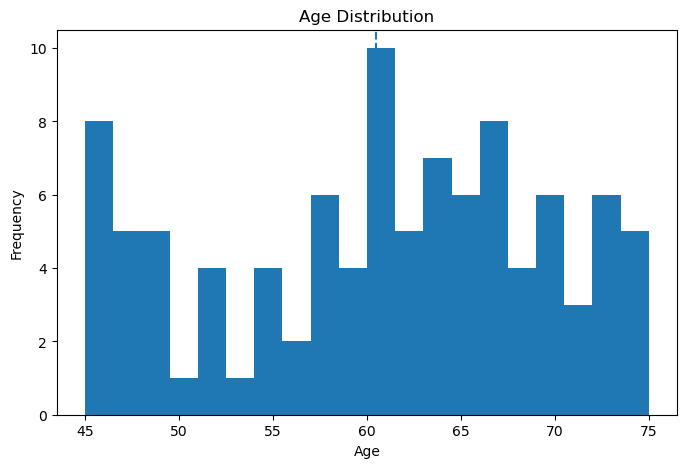

In [2]:
import matplotlib.pyplot as plt

ages = df["Starost"].dropna()


mean_age = ages.mean()

print(f"Mean age: {mean_age:.2f}")


plt.figure(figsize=(8, 5))
plt.hist(ages, bins=20)


plt.axvline(mean_age, linestyle="--")

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

The youngest patient in our data is 45 years old. The oldest is 75 years old. So our age interval is [45-75] and mean is 60



## 10mg is enought to bring blood pressure back to 'More or Less Normal'

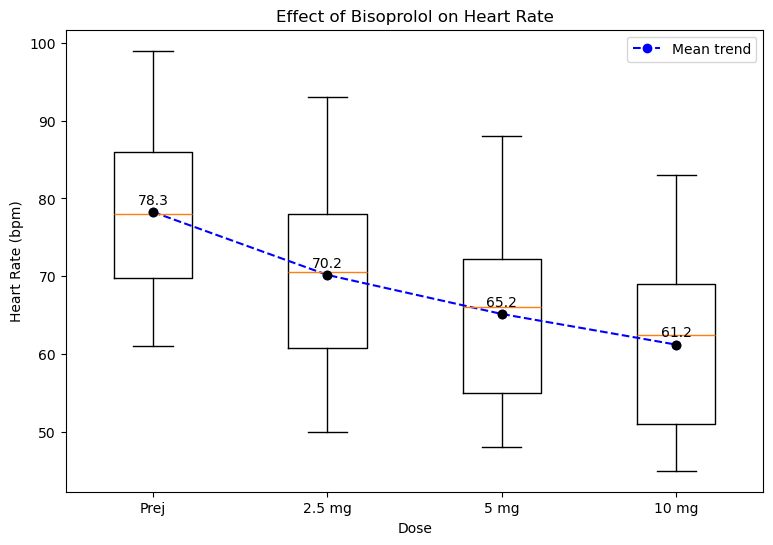

In [3]:
data = [
    df["Srčni Utrip(Prej)"].dropna(),
    df["Srčni Utrip (2.5mg)"].dropna(),
    df["Srčni Utrip (5mg)"].dropna(),
    df["Srčni Utrip (10mg)"].dropna()
]

labels = ["Prej", "2.5 mg", "5 mg", "10 mg"]

plt.figure(figsize=(9, 6))

# boxplot
plt.boxplot(data, tick_labels=labels)

# mean values
means = [d.mean() for d in data]

# trend line
plt.plot(range(1, 5), means, marker="o", linestyle="--", color="blue", label="Mean trend")

# mean points + labels
for i, m in enumerate(means, start=1):
    plt.scatter(i, m, color="black", zorder=3)
    plt.text(i, m + 1, f"{m:.1f}", ha="center")

plt.xlabel("Dose")
plt.ylabel("Heart Rate (bpm)")
plt.title("Effect of Bisoprolol on Heart Rate")

plt.legend()
plt.show()

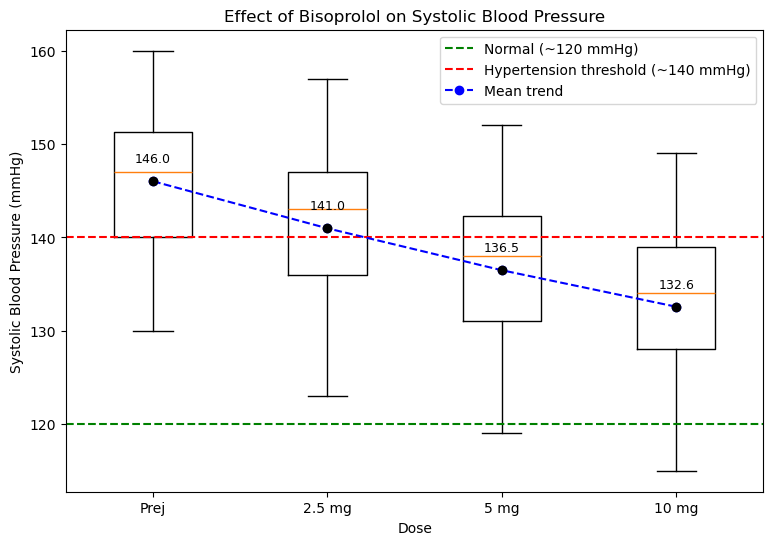

In [4]:
data = [
    df["Sistolični Krvni Tlak(Prej)"].dropna(),
    df["Sistolični Krvni Tlak (2.5mg)"].dropna(),
    df["Sistolični Krvni Tlak (5mg)"].dropna(),
    df["Sistolični Krvni Tlak (10mg)"].dropna()
]

labels = ["Prej", "2.5 mg", "5 mg", "10 mg"]

plt.figure(figsize=(9, 6))

# boxplot
plt.boxplot(data, tick_labels=labels)

# reference lines
plt.axhline(120, color="green", linestyle="--", label="Normal (~120 mmHg)")
plt.axhline(140, color="red", linestyle="--", label="Hypertension threshold (~140 mmHg)")

# mean values
means = [d.mean() for d in data]
plt.plot(range(1, 5), means, marker="o", linestyle="--", color="blue", label="Mean trend")

for i, m in enumerate(means, start=1):
    plt.scatter(i, m, color="black", zorder=3)
    plt.text(i, m + 2, f"{m:.1f}", ha="center", fontsize=9)

plt.xlabel("Dose")
plt.ylabel("Systolic Blood Pressure (mmHg)")
plt.title("Effect of Bisoprolol on Systolic Blood Pressure")

plt.legend()
plt.show()

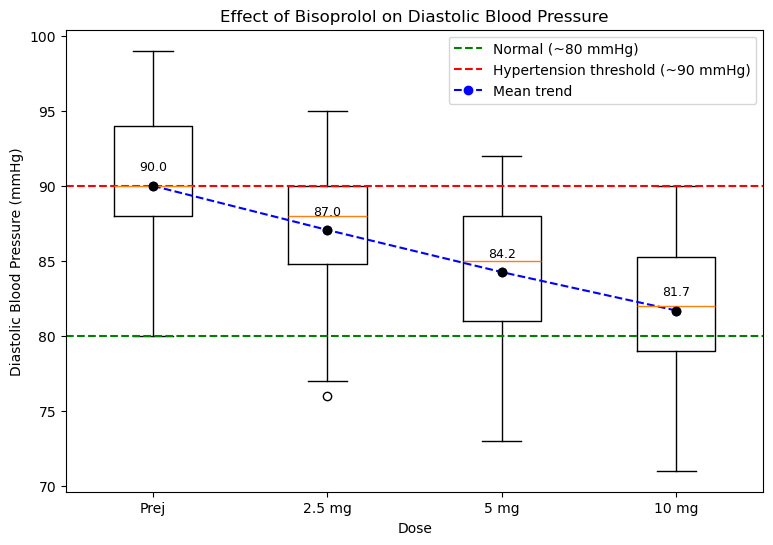

In [5]:
data = [
    df["Diastolični Krvni Tlak(prej)"].dropna(),
    df["Diastolični Krvni Tlak(2.5mg)"].dropna(),
    df["Diastolični Krvni Tlak(5mg)"].dropna(),
    df["Diastolični Krvni Tlak(10mg)"].dropna()
]

labels = ["Prej", "2.5 mg", "5 mg", "10 mg"]

plt.figure(figsize=(9, 6))

# boxplot
plt.boxplot(data, tick_labels=labels)

# clinical reference line (typical normal diastolic ~80)
plt.axhline(80, color="green", linestyle="--", label="Normal (~80 mmHg)")
plt.axhline(90, color="red", linestyle="--", label="Hypertension threshold (~90 mmHg)")

# mean trend
means = [d.mean() for d in data]
plt.plot(range(1, 5), means, marker="o", linestyle="--", color="blue", label="Mean trend")

# annotate means
for i, m in enumerate(means, start=1):
    plt.scatter(i, m, color="black", zorder=3)
    plt.text(i, m + 1, f"{m:.1f}", ha="center", fontsize=9)

plt.xlabel("Dose")
plt.ylabel("Diastolic Blood Pressure (mmHg)")
plt.title("Effect of Bisoprolol on Diastolic Blood Pressure")

plt.legend()
plt.show()

### Linear Regression to see, that Biposorol works(Assuming: Dose ↑ Pressure ↓)

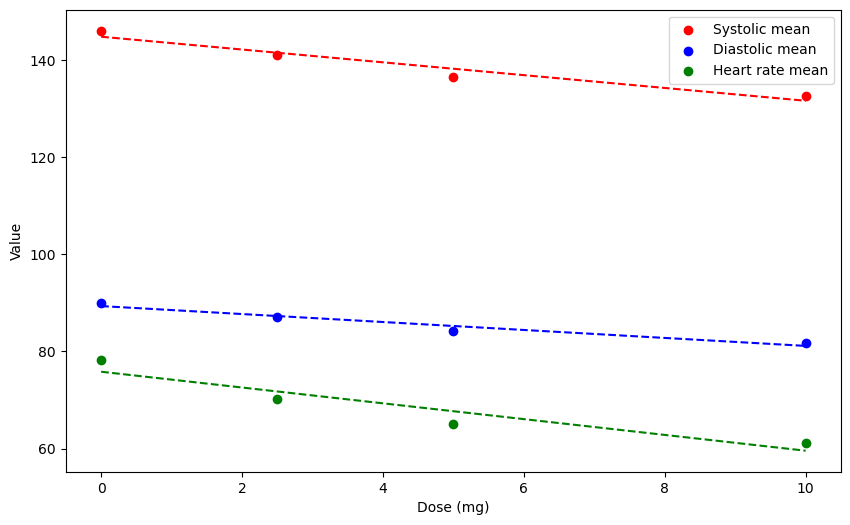

Systolic correlation: -0.9715820408301783
Diastolic correlation: -0.9767357838709
Heart rate correlation: -0.9440794409418022


In [6]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Dose values (numeric)

dose = np.array([0, 2.5, 5, 10]).reshape(-1, 1)

# SYSTOLIC BP means

sys_means = [
    df["Sistolični Krvni Tlak(Prej)"].mean(),
    df["Sistolični Krvni Tlak (2.5mg)"].mean(),
    df["Sistolični Krvni Tlak (5mg)"].mean(),
    df["Sistolični Krvni Tlak (10mg)"].mean()
]


pace_means = [
    df["Srčni Utrip(Prej)"].mean(),
    df["Srčni Utrip (2.5mg)"].mean(),
    df["Srčni Utrip (5mg)"].mean(),
    df["Srčni Utrip (10mg)"].mean()
]


# DIASTOLIC BP means

dia_means = [
    df["Diastolični Krvni Tlak(prej)"].mean(),
    df["Diastolični Krvni Tlak(2.5mg)"].mean(),
    df["Diastolični Krvni Tlak(5mg)"].mean(),
    df["Diastolični Krvni Tlak(10mg)"].mean()
]

# Linear regression models

sys_model = LinearRegression().fit(dose, sys_means)
dia_model = LinearRegression().fit(dose, dia_means)
hr_model  = LinearRegression().fit(dose, pace_means)

# Smooth line
x_line = np.linspace(0, 10, 100).reshape(-1, 1)

sys_pred = sys_model.predict(x_line)
dia_pred = dia_model.predict(x_line)
hr_pred  = hr_model.predict(x_line)


plt.figure(figsize=(10, 6))

plt.scatter(dose, sys_means, color="red", label="Systolic mean")
plt.scatter(dose, dia_means, color="blue", label="Diastolic mean")
plt.scatter(dose, pace_means, color="green", label="Heart rate mean")

plt.plot(x_line, sys_pred, color="red", linestyle="--")
plt.plot(x_line, dia_pred, color="blue", linestyle="--")
plt.plot(x_line, hr_pred, color="green", linestyle="--")

plt.xlabel("Dose (mg)")
plt.ylabel("Value")

plt.legend()
plt.show()


#Calculating correlation coefficient
dose_flat = dose.ravel()

r_sys = np.corrcoef(dose_flat, sys_means)[0, 1]
r_dia = np.corrcoef(dose_flat, dia_means)[0, 1]
r_hr  = np.corrcoef(dose_flat, pace_means)[0, 1]

print("Systolic correlation:", r_sys)
print("Diastolic correlation:", r_dia)
print("Heart rate correlation:", r_hr)

## Creating a LinearRegression Model for predicting parameters of patients

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


# 1. BUILD DATASET 

rows = []

for _, row in df.iterrows():
    baseline_sys = row["Sistolični Krvni Tlak(Prej)"]
    baseline_dia = row["Diastolični Krvni Tlak(prej)"]

    samples = [
        (0, row["Sistolični Krvni Tlak(Prej)"], row["Diastolični Krvni Tlak(prej)"]),
        (2.5, row["Sistolični Krvni Tlak (2.5mg)"], row["Diastolični Krvni Tlak(2.5mg)"]),
        (5, row["Sistolični Krvni Tlak (5mg)"], row["Diastolični Krvni Tlak(5mg)"]),
        (10, row["Sistolični Krvni Tlak (10mg)"], row["Diastolični Krvni Tlak(10mg)"]),
    ]

    for dose, sys, dia in samples:
        if pd.notna(sys) and pd.notna(dia):
            rows.append([
                baseline_sys,
                baseline_dia,
                dose,
                sys - baseline_sys,
                dia - baseline_dia
            ])

data_ml = pd.DataFrame(rows, columns=[
    "baseline_sys", "baseline_dia", "dose",
    "sys_change", "dia_change"
])

# 2. FEATURES AND TARGETS

X = data_ml[["baseline_sys", "baseline_dia", "dose"]]

y_sys = data_ml["sys_change"]
y_dia = data_ml["dia_change"]

# 3. TRAIN / TEST SPLIT (75 / 25)

X_train, X_test, y_sys_train, y_sys_test = train_test_split(
    X, y_sys, test_size=0.25, random_state=42
)

_, _, y_dia_train, y_dia_test = train_test_split(
    X, y_dia, test_size=0.25, random_state=42
)

# 4. TRAIN MODELS

sys_model = LinearRegression()
dia_model = LinearRegression()

sys_model.fit(X_train, y_sys_train)
dia_model.fit(X_train, y_dia_train)


# 5. PREDICTIONS

sys_pred = sys_model.predict(X_test)
dia_pred = dia_model.predict(X_test)

# 6. EVALUATION

print("=== SYSTOLIC MODEL ===")
print("MAE:", mean_absolute_error(y_sys_test, sys_pred))
print("R2:", r2_score(y_sys_test, sys_pred))

print("\n=== DIASTOLIC MODEL ===")
print("MAE:", mean_absolute_error(y_dia_test, dia_pred))
print("R2:", r2_score(y_dia_test, dia_pred))

=== SYSTOLIC MODEL ===
MAE: 1.5422484200412514
R2: 0.8592987157845395

=== DIASTOLIC MODEL ===
MAE: 0.9226057526114466
R2: 0.8460676752586809


This means our model is very good at predicting :)